# Training Faster R-CNN

## 0. Hardware Summary

The following hardware was used for training and validation:

- **CPU:** AMD Ryzen 9 5950X - 16 Cores / 32 Threads
- **RAM:** 64 GB
- **GPU:** NVIDIA GeForce RTX 5070 Ti - 16 GB
- **CUDA:** Version 13.1


## 1. Setup

### i. Necessary Imports


In [14]:
# For model
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.datasets import CocoDetection
from torchvision.models.detection.rpn import AnchorGenerator
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import datetime
import time # yes, ik theres 2. but if it aint broke dont fix it i guess
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval

# For visualization
import matplotlib.pyplot as plt
import pandas as pd

# For data handling
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # avoid kernel crash during training step
import zipfile
import csv
import shutil

### ii. Monitoring

In [15]:
# Enable TensorBoard logging
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
rcnn_writer = SummaryWriter(log_dir=f"runs/rcnn_logs/{current_time}")

print('TensorBoard logging enabled.')

TensorBoard logging enabled.


### iii. Ensure cuda availability

In [16]:
if torch.cuda.is_available():
    print(f'CUDA is available context device: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA is not available. Training will run on CPU.')


CUDA is available context device: NVIDIA GeForce RTX 5070 Ti


### iv. Display dataset folder structure

In [17]:
# /F=show files, /A=use ASCII characters
output = !tree Dataset /F /A

# Print the output skipping the first 3 lines (Header/Path info)
print('Dataset/\n'+'\n'.join(output[3:]))

Dataset/
|   merged_images.zip
|   merged_input.json
|   
+---COCO-Format Annotations
|       COCO.json
|       COCO_condition.json
|       COCO_mounting.json
|       COCO_sign_shape.json
|       COCO_view_angle.json
|       
+---Individuals
|       images_Amy_Spiteri.zip
|       images_Daniel_Pace.zip
|       images_Ellyn_Rose_Debrincat.zip
|       images_Joachim_Grech.zip
|       input_Amy_Spiteri.json
|       input_Daniel_Pace.json
|       input_Ellyn_Rose_Debrincat.json
|       input_Joachim_Grech.json
|       
\---Train-Test-Val Split
    |   images.zip
    |   
    +---COCO-based
    |   +---COCO-based_COCO
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_condition
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_mounting
    |   |   \---annotation

### v. Paths

In [18]:
DATASET_ROOT = './Dataset/Train-Test-Val Split'
IMG_ROOT = os.path.join(DATASET_ROOT, 'images')
ANN_DIR = os.path.join(DATASET_ROOT, "COCO-based/COCO-based_COCO/annotations")

# For unzipping images if needed
ZIP_PATH = os.path.join(DATASET_ROOT, 'images.zip')

### vi. Extract `images.zip` if necessary

In [19]:
# ensure destination is correct
if os.path.exists(DATASET_ROOT):
    
    # Check if the contents are already extracted
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_contents = zip_ref.namelist()
        
        # If there are contents in the zip file
        if zip_contents:
            item_path = os.path.join(DATASET_ROOT, zip_contents[0])
            
            # If the first item in the zip already exists in the extract path, skip extraction
            if os.path.exists(item_path):
                print(f'Contents already extracted to {DATASET_ROOT}. Skipping extraction.')
            
            # Else extract the contents
            else:
                print(f'Extracting {ZIP_PATH} to {DATASET_ROOT}...')
                zip_ref.extractall(DATASET_ROOT)
                print('Extraction complete.')
        else:
            print(f'Zip file {ZIP_PATH} is empty. No extraction performed.')

Contents already extracted to ./Dataset/Train-Test-Val Split. Skipping extraction.


### vii. Dataset & Dataloader config

In [20]:
# --- Train Dataset ---
dataset = CocoDetection(
    root=os.path.join(IMG_ROOT, 'train'),
    annFile=os.path.join(ANN_DIR, 'train.json'),
    transform=torchvision.transforms.Compose([torchvision.transforms.ToTensor(),]))

# --- Val Dataset ---
val_dataset = CocoDetection(
    root=os.path.join(IMG_ROOT, 'val'),
    annFile=os.path.join(ANN_DIR, 'val.json'),
    transform=torchvision.transforms.Compose([torchvision.transforms.ToTensor(),]))

collate_fn = lambda x: tuple(zip(*x))

# Anchor generator
anchor_generator = AnchorGenerator(
    sizes=((16, 32, 64, 128, 256),),  # Added smaller size '16'
    aspect_ratios=((0.5, 1.0, 2.0),) * 5
)

dataloader = DataLoader(
        dataset, 
        batch_size=6,  # default
        shuffle=True, 
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True # apparently faster data transfer to GPU
    )

val_dataloader = DataLoader(
        val_dataset, 
        batch_size=6, 
        shuffle=False, 
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True
    )

# Extract all unique category IDs from the COCO JSON (assumes train contains all possible categories... which it should)
coco_ids = sorted(dataset.coco.getCatIds())
print(f'{len(coco_ids)} unique COCO category IDs found: {coco_ids}')

# Create a safe mapping: {COCO_ID -> MODEL_LABEL}
# Model Label 0 is background
id_map = {coco_id: i + 1 for i, coco_id in enumerate(coco_ids)}

NUM_CLASSES = len(coco_ids) + 1  # +1 for background

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
6 unique COCO category IDs found: [1, 2, 3, 4, 5, 6]


### viii. Model initialisation

In [8]:
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes=7) # 6 classes + background

## 2. Training

### i. Hyperparameters

In [9]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
LEARNING_RATE = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10 # was 20, but im runnning out of patience :D
SAVE_PERIOD = 10 #save every 10 epochs, like im doing for yolo

### ii. Training

In [10]:
# Initialize TensorBoard Writer with a timestamped directory
run_name = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join("runs/rcnn_logs", run_name)
writer = SummaryWriter(log_dir=log_dir)

# Initialize CSV Logger (Mimicking YOLO format)
csv_path = os.path.join(log_dir, "results.csv")
# YOLO headers reference
csv_headers = [
    "epoch", "time", 
    "train/box_loss", "train/cls_loss", "train/dfl_loss", 
    "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)", 
    "val/box_loss", "val/cls_loss", "val/dfl_loss",
    "lr/pg0", "lr/pg1", "lr/pg2"
]
with open(csv_path, mode='w', newline='') as f:
    csv_writer = csv.writer(f)
    csv_writer.writerow(csv_headers)

model.to(DEVICE)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.1)

print(f"Starting training on {DEVICE}...")
print(f"TensorBoard logs and results.csv being saved to: {log_dir}")
print(f"Early stopping patience set to: {EARLY_STOPPING_PATIENCE}")

global_step = 0
best_map = 0.0
best_loss = float('inf') # Fallback if mAP fails
patience_counter = 0

def prepare_batch(images, targets, device):
    images = list(image.to(device) for image in images)
    formatted_targets = []
    original_ids = [] # Keep track of image IDs for evaluation
    
    for t in targets:
        boxes = []
        labels = []
        img_id = t[0]['image_id'] if len(t) > 0 else -1
        
        for obj in t:
            x, y, w, h = obj['bbox']
            if w <= 0 or h <= 0: continue #sanity check
            boxes.append([x, y, x + w, y + h])
            cat_id = obj['category_id']
            labels.append(id_map[cat_id]) # generic 1-based class mapping
        
        if len(boxes) > 0:
            formatted_targets.append({
                'boxes': torch.tensor(boxes, dtype=torch.float32).to(device),
                'labels': torch.tensor(labels, dtype=torch.int64).to(device),
                'image_id': img_id
            })
            original_ids.append(img_id)
        else:
             # Handle empty images if necessary, though RCNN expects targets
             pass
             
    return images, formatted_targets, original_ids

# --- Main Loop ---
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    train_loss_box = 0.0
    train_loss_cls = 0.0
    epoch_loss = 0
    
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch + 1}/{EPOCHS} [Train]")
    
    for i, (images, targets) in pbar:
        images, formatted_targets, _ = prepare_batch(images, targets, DEVICE)
        
        if not formatted_targets: continue

        loss_dict = model(images, formatted_targets)
        losses = sum(loss_dict.values())

        # Backprop
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Logging
        # Map Losses to YOLO-like names:
        # box_loss ~= loss_box_reg + loss_rpn_box_reg
        # cls_loss ~= loss_classifier + loss_objectness
        l_box = loss_dict.get('loss_box_reg', 0) + loss_dict.get('loss_rpn_box_reg', 0)
        l_cls = loss_dict.get('loss_classifier', 0) + loss_dict.get('loss_objectness', 0)
        
        train_loss_box += l_box.item()
        train_loss_cls += l_cls.item()
        epoch_loss += losses.item()
        
        writer.add_scalar("Loss/total", losses.item(), global_step)
        for k, v in loss_dict.items():
            writer.add_scalar(f"Loss_Detailed/{k}", v.item(), global_step)
        
        global_step += 1
        pbar.set_postfix({"Loss": f"{losses.item():.4f}", "LR": f"{optimizer.param_groups[0]['lr']:.6f}"})

    # Averages
    avg_train_loss = epoch_loss / len(dataloader)
    avg_train_box = train_loss_box / len(dataloader)
    avg_train_cls = train_loss_cls / len(dataloader)
    
    # --- Validation Phase (Get Losses & Metrics) ---
    # 1. Validation Loss (Approximate using model.train() + no_grad)
    # Re-enable generic train mode logic for loss calculation only
    val_loss_box = 0.0
    val_loss_cls = 0.0
    
    # We need to temporarily set to train to get loss dict, but ensure no stats update if possible.
    # Standard practice in research scripts is just to use train mode for loss check.
    model.train() 
    
    with torch.no_grad():
        for images, targets in tqdm(val_dataloader, desc="[Val Loss]"):
            images, formatted_targets, _ = prepare_batch(images, targets, DEVICE)
            if not formatted_targets: continue
            loss_dict = model(images, formatted_targets)
            
            l_box = loss_dict.get('loss_box_reg', 0) + loss_dict.get('loss_rpn_box_reg', 0)
            l_cls = loss_dict.get('loss_classifier', 0) + loss_dict.get('loss_objectness', 0)
            val_loss_box += l_box.item()
            val_loss_cls += l_cls.item()

    avg_val_box = val_loss_box / len(val_dataloader)
    avg_val_cls = val_loss_cls / len(val_dataloader)
    
    # 2. Validation Metrics (mAP)
    model.eval()
    coco_results = []
    
    with torch.no_grad():
         for images, targets in tqdm(val_dataloader, desc="[Val Metrics]"):
            # Prepare just images
            images = [img.to(DEVICE) for img in images]
            # Need original image IDs for results
            # targets is list of list of dicts. 
            # We assume batch size 1 or handled correctly. 
            # prepare_batch logic helper for IDs:
            _, _, original_ids = prepare_batch([], targets, DEVICE) # Just extract IDs
            
            outputs = model(images)
            
            # Format results for COCOeval
            for i, output in enumerate(outputs):
                image_id = original_ids[i]
                
                # Move to cpu
                boxes = output['boxes'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                labels = output['labels'].cpu().numpy()
                
                for box, score, label in zip(boxes, scores, labels):
                    # xyxy -> xywh
                    x1, y1, x2, y2 = box
                    w, h = x2 - x1, y2 - y1
                    
                    coco_results.append({
                        'image_id': image_id,
                        'category_id': label, # Note: Ensure this matches val_dataset category IDs
                        'bbox': [x1, y1, w, h],
                        'score': score
                    })

    # Metric Calculation
    mAP50 = 0.0
    mAP50_95 = 0.0
    recall = 0.0
    
    if len(coco_results) > 0:
        coco_gt = val_dataset.coco
        coco_dt = coco_gt.loadRes(coco_results)
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        
        mAP50_95 = coco_eval.stats[0]
        mAP50 = coco_eval.stats[1]
        recall = coco_eval.stats[8] # AR @ IoU=0.50:0.95 | area=all | maxDets=100 (Usually Recall)
    
    # --- Logging & CSV ---
    now = time.time()
    epoch_duration = (now - epoch_start_time) / 3600 # hours? Or just ignore unit
    

    lr_scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Columns: epoch,time,train/box,train/cls,train/dfl,P,R,mAP50,mAP50-95,val/box,val/cls,val/dfl,lr0...
    csv_row = [
        epoch + 1,
        f"{epoch_duration:.4f}",
        f"{avg_train_box:.5f}",
        f"{avg_train_cls:.5f}",
        "0.0", # train/dfl_loss
        "-1", # Precision (Hard to calc exact YOLO def)
        f"{recall:.5f}", # Recall
        f"{mAP50:.5f}",
        f"{mAP50_95:.5f}",
        f"{avg_val_box:.5f}",
        f"{avg_val_cls:.5f}",
        "0.0", # val/dfl_loss
        f"{current_lr:.6f}",
        "0","0" # extra LRs
    ]
    
    with open(csv_path, mode='a', newline='') as f:
        csv_writer = csv.writer(f)
        csv_writer.writerow(csv_row)
        
    writer.add_scalar("metrics/mAP50(B)", mAP50, epoch)
    writer.add_scalar("metrics/mAP50-95(B)", mAP50_95, epoch)
    writer.add_scalar("Loss/val_box", avg_val_box, epoch)
    
    writer.add_scalar('metrics/recall(B)', recall, epoch)
    
    writer.add_scalar('train/box_loss', avg_train_box, epoch)
    writer.add_scalar('train/cls_loss', avg_train_cls, epoch)
    writer.add_scalar('train/dfl_loss', 0.0, epoch)  # Placeholder for DFL loss if applicable
    
    writer.add_scalar('val/box_loss', avg_val_box, epoch)
    writer.add_scalar('val/cls_loss', avg_val_cls, epoch)
    writer.add_scalar('val/dfl_loss', 0.0, epoch)  # Placeholder for DFL loss if applicable
    
    print(f"Epoch {epoch + 1} Summary: mAP50-95: {mAP50_95:.4f} | mAP50: {mAP50:.4f} | Val Loss: {avg_val_box + avg_val_cls:.4f}")

    # --- Save & Early Stopping ---
    
    # Periodic Save
    if (epoch + 1) % SAVE_PERIOD == 0:
        periodic_name = f"faster_rcnn_epoch_{epoch+1}.pt"
        save_path = os.path.join(log_dir, periodic_name) # Save to logs folder
        torch.save(model.state_dict(), save_path)
        print(f"Periodic model saved: {save_path}")

    # Use mAP50-95 as primary metric if available, else loss
    monitor_metric = mAP50_95
    
    if mAP50_95 > best_map:
        best_map = mAP50_95
        patience_counter = 0
        torch.save(model.state_dict(), "faster_rcnn_best.pt")
        print(f"New best model saved! (mAP50-95: {best_map:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break
            
writer.close()
# Save the last model at the end of training
torch.save(model.state_dict(), "faster_rcnn_last.pt")
print(f"Training complete. Last model saved to faster_rcnn_last.pt. Results saved to {csv_path}")

Starting training on cuda...
TensorBoard logs and results.csv being saved to: runs/rcnn_logs\20260117-120653
Early stopping patience set to: 10


[Val Metrics]: 100%|██████████| 19/19 [00:18<00:00,  1.02it/s]


Starting training on cuda...
TensorBoard logs and results.csv being saved to: runs/rcnn_logs\20260117-120653
Early stopping patience set to: 10


[Val Metrics]: 100%|██████████| 19/19 [00:18<00:00,  1.02it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.246
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.409
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.259
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.125
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.082
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.278
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.376
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.590
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.596
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

...

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.588
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.706
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.677
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.202
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.661
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.623
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.680
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.680
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

[Val Metrics]: 100%|██████████| 19/19 [00:18<00:00,  1.04it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.581
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.702
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.674
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.200
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.651
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.628
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.684
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.684
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

[Val Metrics]: 100%|██████████| 19/19 [00:18<00:00,  1.03it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.586
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.708
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.680
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.202
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.657
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.633
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.689
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.689
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

## 3. Testing & Evaluation

### i. Paths

In [21]:
TEST_PATH = os.path.join(DATASET_ROOT, 'YOLO', 'YOLO_COCO', 'images', 'test')
yolo_csv = os.path.join('runs', 'yolo12l_general_signs', 'results.csv')
rcnn_csv = os.path.join('runs', 'rcnn_logs', run_name, 'results.csv')

### iii. Display tests

Comparing against latest R-CNN log: runs\rcnn_logs\20260117-120653\results.csv


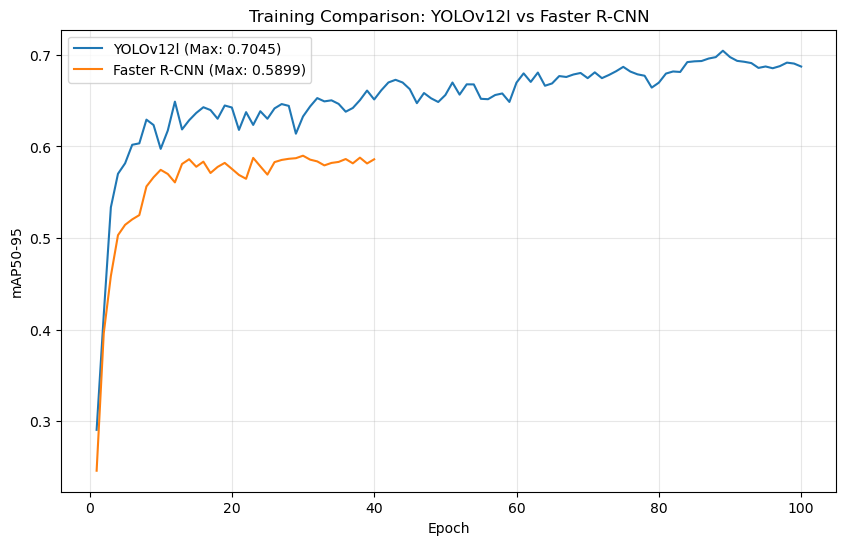

In [22]:
print(f"Comparing against latest R-CNN log: {rcnn_csv}")

# Load Data
try:
    df_yolo = pd.read_csv(yolo_csv)
    df_yolo.columns = df_yolo.columns.str.strip() # Clean YOLO headers
    
    df_rcnn = pd.read_csv(rcnn_csv)
    df_rcnn.columns = df_rcnn.columns.str.strip() # Clean R-CNN headers
    
    # Plot
    plt.figure(figsize=(10, 6))
    
    # YOLO curve
    if 'metrics/mAP50-95(B)' in df_yolo.columns:
        plt.plot(df_yolo['epoch'], df_yolo['metrics/mAP50-95(B)'], 
                    label=f"YOLOv12l (Max: {df_yolo['metrics/mAP50-95(B)'].max():.4f})")
                    
    # R-CNN curve
    if 'metrics/mAP50-95(B)' in df_rcnn.columns:
        plt.plot(df_rcnn['epoch'], df_rcnn['metrics/mAP50-95(B)'], 
                    label=f"Faster R-CNN (Max: {df_rcnn['metrics/mAP50-95(B)'].max():.4f})")
    
    plt.xlabel('Epoch')
    plt.ylabel('mAP50-95')
    plt.title('Training Comparison: YOLOv12l vs Faster R-CNN')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
except Exception as e:
    print(f"Error loading CSVs: {e}")

## 4. Clean Up Files

In [23]:
# remove the images folder to save space
images_path = os.path.join(DATASET_ROOT, 'images')
if os.path.exists(images_path):
    shutil.rmtree(images_path)
    print(f"Removed images folder at {images_path} to save space.")
    

Removed images folder at ./Dataset/Train-Test-Val Split\images to save space.
